In [1]:
import sys
if '/home/vwetzell/gitrepos' not in sys.path:
    sys.path.insert(0, '/home/vwetzell/gitrepos')

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
%matplotlib inline

# bfd_cnf package imports
from bfd_cnf.config import key, Sigma0, PRIOR_FLOW_PATH, Q_FLOW_PATH, GRID_P_PATH, GRID_M_PATH, prior_sigmax_log_scale_mean
from bfd_cnf.data import load_data, transform_dataset_to_standard, make_augmentation_noise_raw_jax
from bfd_cnf.training import load_or_train
from bfd_cnf.inference import (
    make_flow_prob_and_derivs,
    rqmc_integrate_pqr_jax,
    rqmc_pqr_grid,
    load_grid_data,
    assemble_pqr_from_flow,
)
from bfd_cnf.statistics import pqr2g, pqr2multbias, clipR, bootstrap_total_mult_bias
from bfd_cnf.viz import (
    plot_snr_histograms,
    plot_moment_corner,
    plot_resampled_corner,
    plot_flow_vs_obs_corner,
    plot_prob_derivs_m1mr_m2mr,
    plot_prob_derivs_log10mf_mrmf,
    plot_Q_distributions,
    plot_R_distributions,
    plot_g_comparison,
    plot_g_distributions,
    plot_mult_bias_hexbin,
)

In [15]:
data = load_data(key=key, subsample=1)
moments_jnp = data["moments_jnp"]
odd_moments_jnp = data["odd_moments_jnp"]
cov_jnp = data["cov_jnp"]
dm_dg_jnp = data["dm_dg_jnp"]
d2m_dg2_jnp = data["d2m_dg2_jnp"]
weights = data["weights"]
resampled = data["resampled"]
data_mean = data["data_mean"]
data_std = data["data_std"]
raw2standard = data["raw2standard"]
x_lo, x_hi = data["x_lo"], data["x_hi"]
y_lo, y_hi = data["y_lo"], data["y_hi"]
key = data["key"]

print(f"Loaded {moments_jnp.shape[0]} templates")
print(
    f"Selection box: log10(Mf) in [{x_lo:.2f}, {x_hi:.2f}], Mr/Mf in [{y_lo:.2f}, {y_hi:.2f}]"
)

/home/vwetzell/gitrepos/bfd_cnf/data.py:372: RuntimeWarning: divide by zero encountered in divide
  + cov[:, 2, 2] / moments[:, 2] ** 2
/home/vwetzell/gitrepos/bfd_cnf/data.py:373: RuntimeWarning: divide by zero encountered in divide
  - 2 * cov[:, 1, 2] / (moments[:, 1] * moments[:, 2])
/home/vwetzell/gitrepos/bfd_cnf/data.py:370: RuntimeWarning: invalid value encountered in multiply
  m1mr_err = np.abs(m1mr) * np.sqrt(


Fitted log p(x,y) = -7.920 + -1.742x + 8.658y + -0.190x^2 + -1.514y^2 + 0.325xy
ESS fraction inside box: 0.123
Loaded 11974517 templates
Selection box: log10(Mf) in [3.00, 5.70], Mr/Mf in [0.50, 9.00]


In [16]:
odd_moments_jnp.shape

(11974517, 2)

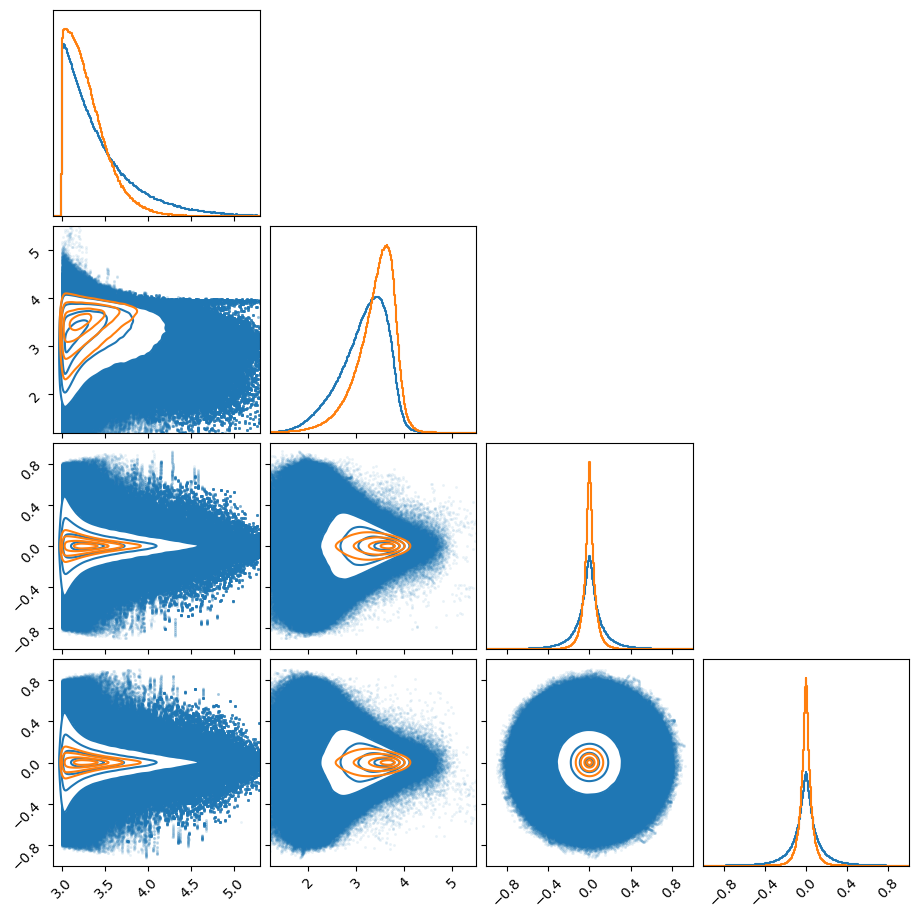

In [17]:
import corner

X_cov_jnp = 400**2 * jnp.eye(
    odd_moments_jnp.shape[1]
)  # Identity covariance for weighting


X_weights = jnp.exp(
    -0.5
    * jnp.einsum(
        "...i,ij,...j->...", odd_moments_jnp, jnp.linalg.inv(X_cov_jnp), odd_moments_jnp
    )
)

standard_moments = jnp.stack(
    [
        jnp.log10(moments_jnp[:, 0]),
        moments_jnp[:, 1] / moments_jnp[:, 0],
        moments_jnp[:, 2] / moments_jnp[:, 1],
        moments_jnp[:, 3] / moments_jnp[:, 1],
    ],
    axis=-1,
)

fig = plt.figure(figsize=(10, 10))
corner.corner(
    np.array(standard_moments),
    weights=np.ones_like(X_weights)/np.sum(np.ones_like(X_weights)),
    bins=500,
    plot_datapoints=True,
    plot_density=False,
    plot_contours=True,
    fill_contours=False,
    hist_kwargs={"label": "Observed Templates"},
    smooth=5.0,
    smooth1d=1.0,
    color="tab:blue",
    range=((np.log10(800), np.log10(200000)), (1.2, 5.5), (-1.0, 1.0), (-1.0, 1.0)),
    fig=fig,
)
corner.corner(
    np.array(standard_moments),
    weights=np.array(X_weights)/np.sum(X_weights),
    bins=500,
    plot_datapoints=False,
    plot_density=False,
    plot_contours=True,
    fill_contours=False,
    hist_kwargs={"label": "Observed Templates"},
    smooth=5.0,
    smooth1d=1.0,
    color="tab:orange",
    range=((np.log10(800), np.log10(200000)), (1.2, 5.5), (-1.0, 1.0), (-1.0, 1.0)),
    fig=fig,
)
plt.show()